In [2]:
# Ejecutar en una celda del notebook
%pip install contextily geopandas sqlalchemy psycopg2-binary python-dotenv matplotlib pandas scikit-learn

  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ------------------------------ --------- 6.6/8.7 MB 32.5 MB/s eta 0:00:01
   ---------------------------------------- 8.7/8.7 MB 30.5 MB/s  0:00:00
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/38.5 MB 24.4 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/38.5 MB 28.8 MB/s eta 0:00:01
   ------------------ --------------------- 18.1/38.5 MB 27.7 MB/s eta 0:00:01
   ------------------------ --------------- 23.6/38.5 MB 27.5 MB/s eta 0:00:01
   -------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import os, glob
print("Current working dir:", os.getcwd())

rel = "data/processed/GEE/sanbernardo_indices_2022_ALL_INDICES.tif"
print("Relative path exists?", os.path.exists(rel))
print("List files in folder:", glob.glob("data/processed/GEE/*.tif"))
print("Absolute candidate path from repo root:")
abs_candidate = os.path.abspath(rel)
print(abs_candidate, os.path.exists(abs_candidate))

Current working dir: c:\Users\Public\Desktop\Geoinformatica\geoSanBernardo\notebooks
Relative path exists? False
List files in folder: []
Absolute candidate path from repo root:
c:\Users\Public\Desktop\Geoinformatica\geoSanBernardo\notebooks\data\processed\GEE\sanbernardo_indices_2022_ALL_INDICES.tif False


In [ ]:
from sqlalchemy import create_engine
import geopandas as gpd
import contextily as ctx
import numpy as np
from sklearn.cluster import DBSCAN

# Conexión a PostGIS y funciones básicas para consultar y graficar capas
# Guardar como, por ejemplo, db_plot_utils.py
#
# Dependencias: pip install geopandas sqlalchemy psycopg2-binary contextily matplotlib

import matplotlib.pyplot as plt

# --- CONFIG: completar con tus credenciales ---
DB = {
    "user": "geouser",
    "password": "geopass",
    "host": "localhost",
    "port": 55432,
    "dbname": "geodatabase"
}
# cadena SQLAlchemy (usa psycopg2)
CONN_STR = "postgresql+psycopg2://{user}:{password}@{host}:{port}/{dbname}".format(**DB)



# Agrupar (dissolve) por codigo_dis y hacer clustering espacial (DBSCAN sobre centroides)
engine = get_engine()

# Leer la capa de manzanas
gdf_manzanas = read_layer(engine, schema="public", table="manzanas_zan_bernardo")

# 1) Agrupar/dissolver por codigo_dis (fusiona geometrías por distrito)
gdf_distritos = gdf_manzanas.dissolve(by="codigo_dis")
gdf_distritos = gdf_distritos.reset_index()

# Añadir conteo de manzanas por codigo_dis
counts = gdf_manzanas.groupby("codigo_dis").size().rename("n_manzanas").reset_index()
gdf_distritos = gdf_distritos.merge(counts, on="codigo_dis", how="left")

# Graficar distritos resultantes coloreando por número de manzanas
plot_gdf(gdf_distritos, column="n_manzanas")
plt.title("Manzanas agrupadas por codigo_dis (n_manzanas)")
plt.show()

# 2) Clustering espacial: ejemplo con DBSCAN aplicado sobre centroides de manzana

# proyectar a métrica (EPSG:3857) y calcular centroides
gdf_pts = gdf_manzanas.to_crs(epsg=3857).copy()
centroids = gdf_pts.geometry.centroid
coords = np.vstack([ (p.x, p.y) for p in centroids ])

# Configurar DBSCAN (eps en metros — ajustar según escala/densidad local)
db = DBSCAN(eps=200, min_samples=5, metric="euclidean")
labels = db.fit_predict(coords)

# Añadir etiquetas de cluster al GeoDataFrame original (label -1 = ruido)
gdf_manzanas["cluster"] = labels

# Visualizar clusters (usa plot_gdf que reprojecta a 3857 si add_basemap=True)
plot_gdf(gdf_manzanas, column="cluster", cmap="tab20")
plt.title("Clusters DBSCAN sobre manzanas (label -1 = ruido)")
plt.show()

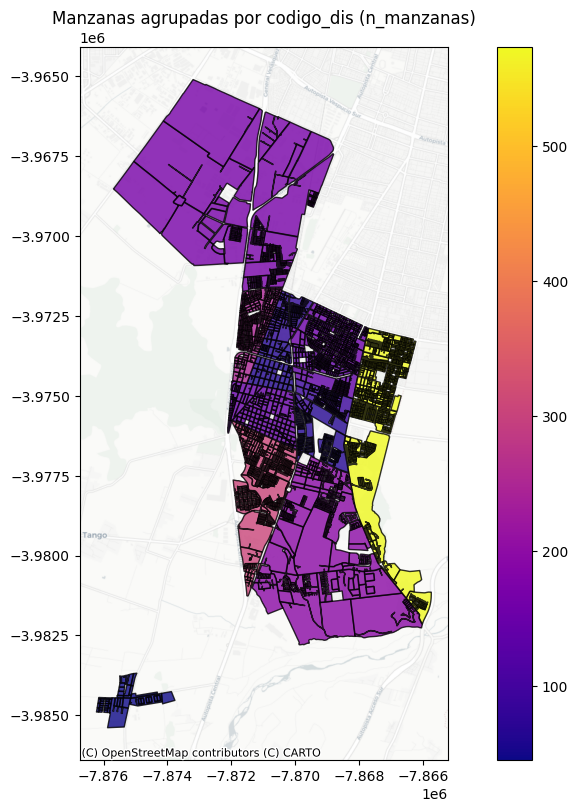

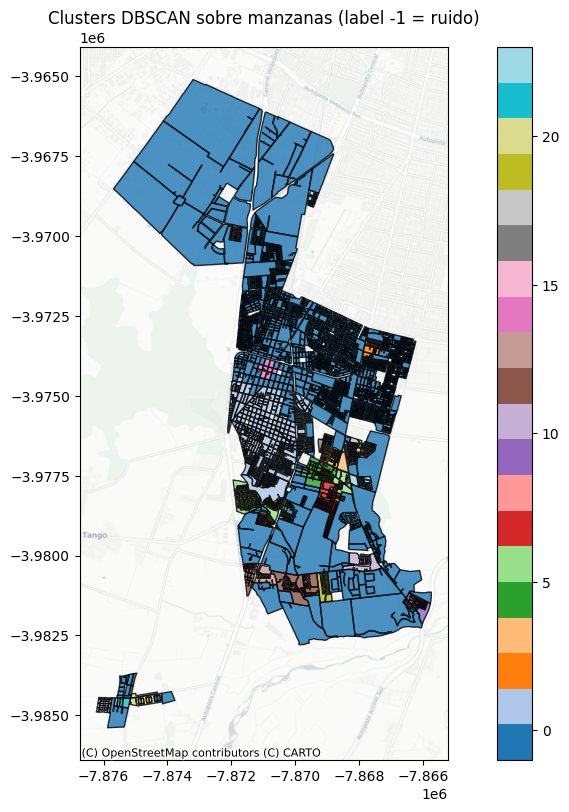

In [3]:
from sqlalchemy import create_engine
import geopandas as gpd
import contextily as ctx
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# --- CONFIG BD ---
DB = {
    "user": "geouser",
    "password": "geopass",
    "host": "localhost",
    "port": 55432,
    "dbname": "geodatabase",
}

CONN_STR = "postgresql+psycopg2://{user}:{password}@{host}:{port}/{dbname}".format(**DB)


def get_engine(conn_str: str = CONN_STR):
    return create_engine(conn_str)


def read_layer(engine, schema: str, table: str, geom_col: str = "geom"):
    sql = f'SELECT * FROM "{schema}"."{table}"'
    # La capa ya está en 3857, así que no hace falta poner crs aquí
    gdf = gpd.read_postgis(sql, engine, geom_col=geom_col)
    return gdf


def plot_gdf(
    gdf: gpd.GeoDataFrame,
    column: str = None,
    cmap: str = "viridis",
    add_basemap: bool = True,
    figsize=(10, 8),
    alpha: float = 0.8,
    edgecolor: str = "k",
):
    # Tu capa ya viene en 3857, así que solo aseguramos el CRS
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=3857)
    gdf_plot = gdf

    ax = gdf_plot.plot(
        column=column,
        cmap=cmap if column is not None else None,
        figsize=figsize,
        alpha=alpha,
        edgecolor=edgecolor,
        legend=column is not None,
    )

    if add_basemap:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    plt.tight_layout()
    return ax


# ============ PIPELINE ============

engine = get_engine()

# OJO: nombre de la tabla y columna geom según tu info
gdf_manzanas = read_layer(
    engine,
    schema="public",
    table="manzanas_san_bernardo",
    geom_col="geom",
)

# Asegurar CRS correcto (EPSG:3857 según QGIS)
if gdf_manzanas.crs is None:
    gdf_manzanas = gdf_manzanas.set_crs(epsg=3857)

# 1) Dissolve por codigo_dis
gdf_distritos = gdf_manzanas.dissolve(by="codigo_dis").reset_index()

counts = (
    gdf_manzanas.groupby("codigo_dis")
    .size()
    .rename("n_manzanas")
    .reset_index()
)
gdf_distritos = gdf_distritos.merge(counts, on="codigo_dis", how="left")

plot_gdf(gdf_distritos, column="n_manzanas", cmap="plasma")
plt.title("Manzanas agrupadas por codigo_dis (n_manzanas)")
plt.show()

# 2) Clustering DBSCAN sobre centroides

# Ya está en 3857 (metros), no reproyectamos de nuevo
gdf_pts = gdf_manzanas.copy()
centroids = gdf_pts.geometry.centroid
coords = np.vstack([(p.x, p.y) for p in centroids])

db = DBSCAN(eps=200, min_samples=5, metric="euclidean")
labels = db.fit_predict(coords)

gdf_manzanas["cluster"] = labels

plot_gdf(gdf_manzanas, column="cluster", cmap="tab20")
plt.title("Clusters DBSCAN sobre manzanas (label -1 = ruido)")
plt.show()

C:\Users\isido\AppData\Local\Temp\ipykernel_17204\824749870.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(gdf_distritos_sorted["nombre_dis"].astype(str), rotation=60)


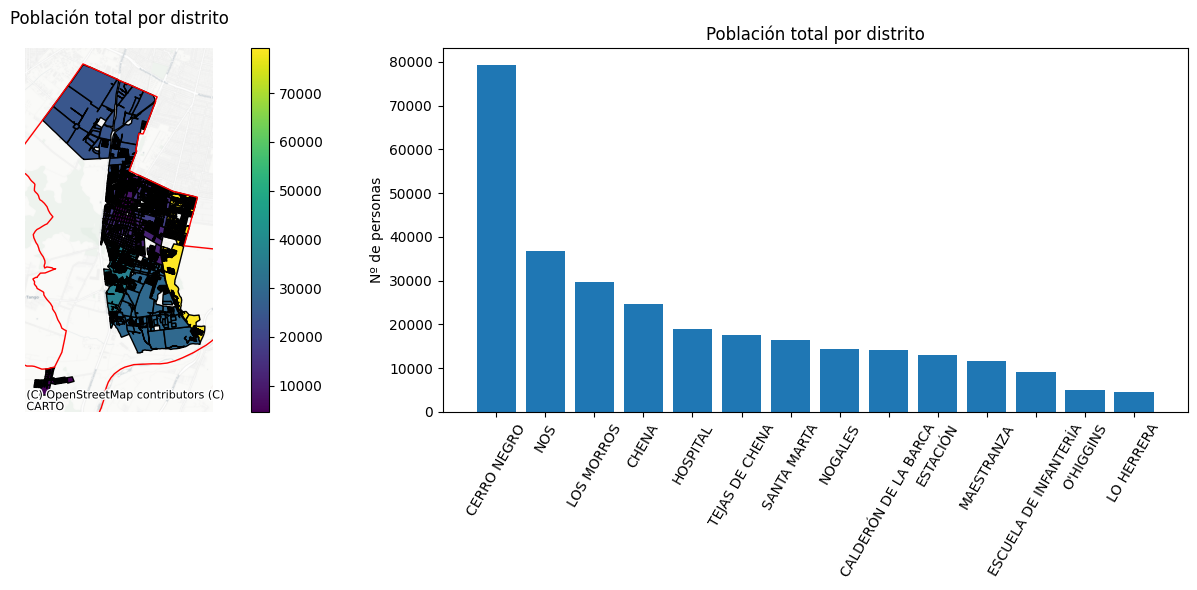

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Asegurar CRS (EPSG:3857 según la capa)
if gdf_manzanas.crs is None:
    gdf_manzanas = gdf_manzanas.set_crs(epsg=3857)

# 1) Agregar: población total por distrito (codigo_dis)
gdf_distritos = (
    gdf_manzanas
    .dissolve(by="nombre_dis", aggfunc={"total_pers": "sum"})
    .reset_index()
)

# Renombrar la columna de población para claridad
gdf_distritos = gdf_distritos.rename(columns={"total_pers": "pers_distrito"})

# 2) Mapa coroplético: nº de personas por distrito
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

gdf_distritos.plot(
    column="pers_distrito",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    ax=ax[0]
)

ctx.add_basemap(ax[0], source=ctx.providers.CartoDB.Positron)
ax[0].set_title("Población total por distrito")
ax[0].axis("off")

# 3) Gráfico de barras: nº de personas por distrito
# 1) Recortar manzanas al límite de San Bernardo
gdf_manzanas_sb = gdf_manzanas.clip(gdf_limite)

# 2) (opcional) graficar para verificar
gdf_limite.boundary.plot(ax=ax[0], color="red", linewidth=1.0)

gdf_distritos_sorted = gdf_distritos.sort_values("pers_distrito", ascending=False)

ax[1].bar(
    gdf_distritos_sorted["nombre_dis"].astype(str),
    gdf_distritos_sorted["pers_distrito"]
)
ax[1].set_xticklabels(gdf_distritos_sorted["nombre_dis"].astype(str), rotation=60)
ax[1].set_ylabel("Nº de personas")
ax[1].set_title("Población total por distrito")

plt.tight_layout()
plt.show()


(np.float64(-7885418.549839038),
 np.float64(-7861243.574322189),
 np.float64(-3997366.2822640724),
 np.float64(-3963523.0872752047))

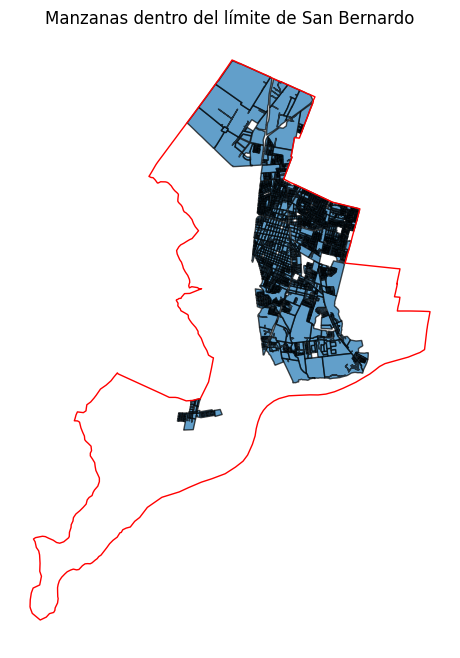

In [10]:
import geopandas as gpd

# OJO: nombre de la tabla y columna geom según tu info
gdf_limite = read_layer(
    engine,
    schema="public",
    table="limite_3857",
    geom_col="geom",
)

# Asegurar mismo CRS (ajusta epsg si tu límite viene en otro)
if gdf_limite.crs is None:
    gdf_limite = gdf_limite.set_crs(epsg=3857)
if gdf_manzanas.crs is None:
    gdf_manzanas = gdf_manzanas.set_crs(epsg=3857)

gdf_limite = gdf_limite.to_crs(gdf_manzanas.crs)

# 1) Recortar manzanas al límite de San Bernardo
gdf_manzanas_sb = gdf_manzanas.clip(gdf_limite)

# 2) (opcional) graficar para verificar
ax = gdf_manzanas_sb.plot(figsize=(8, 8), edgecolor="black", alpha=0.7)
gdf_limite.boundary.plot(ax=ax, color="red", linewidth=1.0)
ax.set_title("Manzanas dentro del límite de San Bernardo")
ax.axis("off")


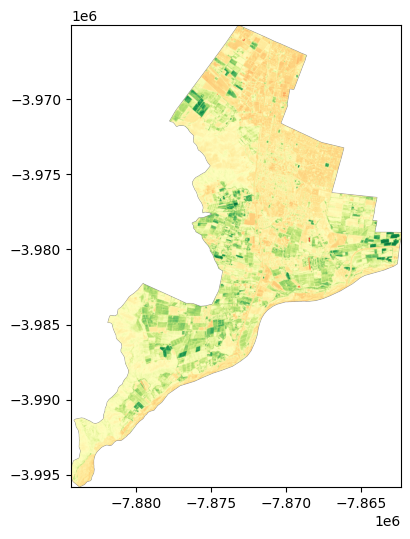

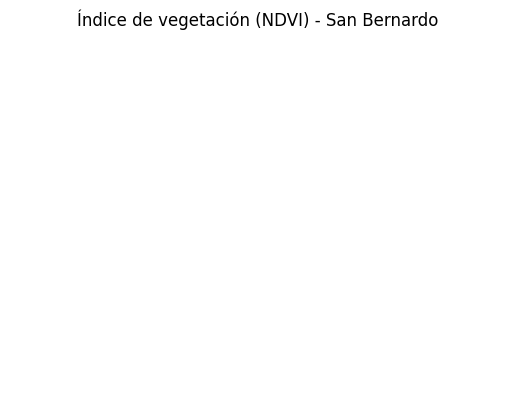

In [19]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Ruta al archivo NDVI exportado desde GEE
ndvi_path = "C:\\Users\\Public\\Desktop\\Geoinformatica\\geoSanBernardo\\data\\processed\\GEE\\sanbernardo_indices_2022_ALL_INDICES.tif"  # ajusta el nombre/ruta

# Abrir raster
ndvi_src = rasterio.open(ndvi_path)

# Mostrar mapa de NDVI
plt.figure(figsize=(8, 6))
show(ndvi_src, cmap="RdYlGn")  # verde = mayor índice de vegetación
plt.title("Índice de vegetación (NDVI) - San Bernardo")
plt.axis("off")
plt.show()


In [ ]:
# NO sirve
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# 1) Abrir raster NDVI
ndvi_path = "C:\\Users\\Public\\Desktop\\Geoinformatica\\geoSanBernardo\\data\\processed\\GEE\\sanbernardo_indices_2022_ALL_INDICES.tif"  # ajusta ruta/nombre si es distinto

with rasterio.open(ndvi_path) as src:
    # 2) Asegurar que manzanas estén en el mismo CRS que el raster
    if gdf_manzanas.crs is None:
        gdf_manzanas = gdf_manzanas.set_crs(src.crs)
    else:
        gdf_manzanas = gdf_manzanas.to_crs(src.crs)

    # 3) Crear figura y eje compartido
    fig, ax = plt.subplots(figsize=(6, 8))

    # Raster NDVI
    show(src, cmap="RdYlGn", ax=ax)

    # Manzanas encima, solo borde para no tapar el raster
    gdf_manzanas.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.3,
        alpha=0.8,
    )

    ax.set_title("NDVI + manzanas censales - San Bernardo")
    ax.axis("off")

plt.tight_layout()
plt.show()
